In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지

plt.rcParams['axes.unicode_minus'] = False

In [55]:
base_path = r"C:\kdt_0900_lsu\ml\resource\datasets"
file_name = r"telecom_customer.csv"

file_path = os.path.join(base_path, file_name)

In [56]:
df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 텔레콤 고객 이탈 데이터셋
[텔레콤 고객 이탈 데이터셋](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## 텔레콤 고객 이탈 데이터셋 컬럼
| 컬럼명 | 설명 |
| :--- | :--- |
| customerID | 고객 고유 식별자 |
| gender | 성별 |
| SeniorCitizen | 고령자 여부 (65세 이상) |
| Partner | 배우자 유무 |
| Dependents | 부양가족 유무 |
| tenure | 서비스 가입 기간 (개월 수) |
| PhoneService | 전화 서비스 가입 여부 |
| MultipleLines | 다중 회선 사용 여부 |
| InternetService | 인터넷 서비스 제공 방식 |
| OnlineSecurity | 온라인 보안 서비스 이용 여부 |
| OnlineBackup | 온라인 백업 서비스 이용 여부 |
| DeviceProtection | 기기 보호 옵션 이용 여부 |
| TechSupport | 전담 기술 지원 서비스 이용 여부 |
| StreamingTV | 스트리밍 TV 서비스 이용 여부 |
| StreamingMovies | 스트리밍 영화 서비스 이용 여부 |
| Contract | 계약 형태 (월 단위, 1년, 2년) |
| PaperlessBilling | 전자 청구서 이용 여부 |
| PaymentMethod | 결제 수단 |
| MonthlyCharges | 월 청구 금액 |
| TotalCharges | 누적 총 청구 금액 |
| Churn | 고객 이탈 여부 (예측 대상) |

In [57]:
telecom_df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
telecom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# 랜덤포레스트 실습

## 파생변수 생성

In [59]:
telecom_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [60]:
telecom_df ["FamilySize"] = 1 + (telecom_df["Partner"] == "Yes").astype(int) + (telecom_df["Dependents"] == "Yes"). astype(int)

In [61]:
telecom_df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilySize
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2


In [62]:
service_columns = [
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"

]
# 총 서비스를 가입한 수 
telecom_df["TotalServices"] = ( telecom_df[service_columns] == "Yes").sum(axis=1)

<Axes: xlabel='TotalServices', ylabel='Churn'>

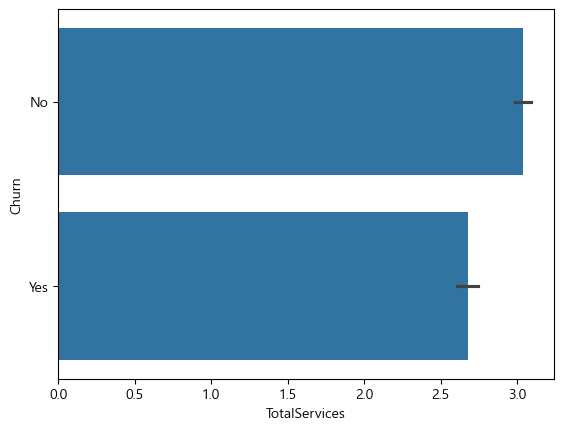

In [63]:
# 총 서비스 vs 이탈률
sns.barplot(telecom_df, x="TotalServices", y ="Churn")

In [64]:
telecom_df["Churn"] = (telecom_df["Churn"] == "Yes").astype(int)

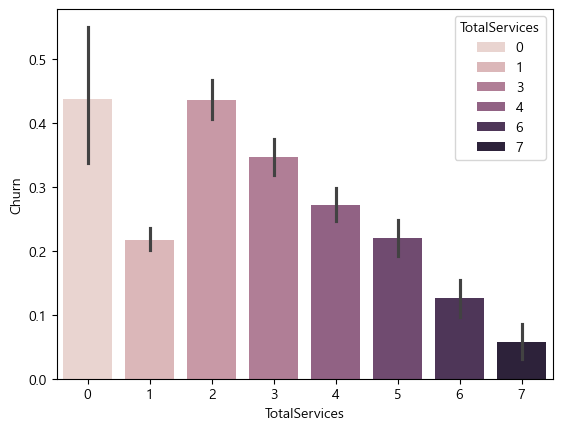

In [65]:
# 총서비스, 이동률
sns.barplot(telecom_df, x="TotalServices", y="Churn", hue = "TotalServices")
plt.show()

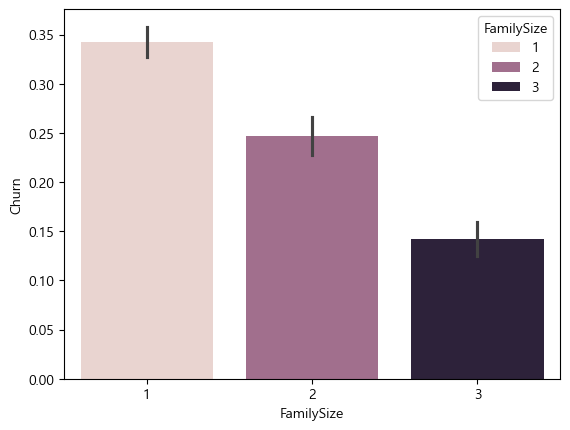

In [66]:
sns.barplot(telecom_df, x="FamilySize", y= "Churn", hue = "FamilySize")
plt.show()

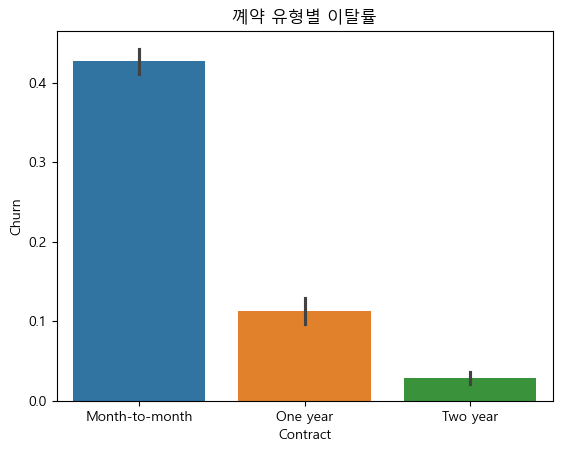

In [67]:
sns.barplot(telecom_df, x="Contract", y="Churn", hue ="Contract")
plt.title("꼐약 유형별 이탈률")
plt.show()

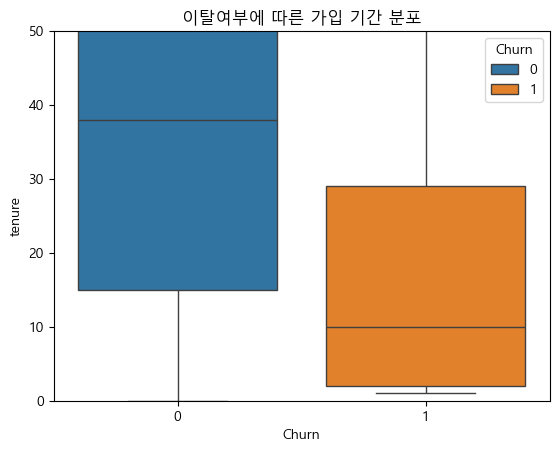

In [84]:
sns.boxplot(telecom_df, x="Churn", y="tenure", hue = "Churn")
plt.title("이탈여부에 따른 가입 기간 분포")
plt.ylim(0, 50)
plt.show()

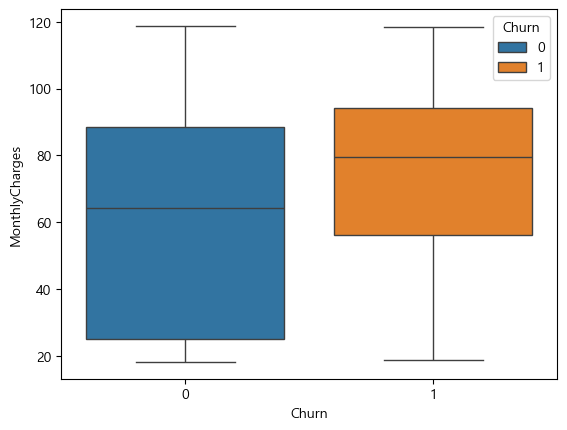

In [85]:
sns.boxplot(telecom_df, x="Churn", y="MonthlyCharges", hue="Churn")
plt.show()

In [86]:
X = telecom_df.drop("Churn", axis=1)
y = telecom_df["Churn"]

In [87]:
for col in X.columns:
    # print(X[col]. unique())
    print(f"{col:<20} 개수: {x[col].nunique()}개")

customerID           개수: 7043개
gender               개수: 2개
SeniorCitizen        개수: 2개
Partner              개수: 2개
Dependents           개수: 2개
tenure               개수: 73개
PhoneService         개수: 2개
MultipleLines        개수: 3개
InternetService      개수: 3개
OnlineSecurity       개수: 3개
OnlineBackup         개수: 3개
DeviceProtection     개수: 3개
TechSupport          개수: 3개
StreamingTV          개수: 3개
StreamingMovies      개수: 3개
Contract             개수: 3개
PaperlessBilling     개수: 2개
PaymentMethod        개수: 4개
MonthlyCharges       개수: 1585개
TotalCharges         개수: 6531개
FamilySize           개수: 3개
TotalServices        개수: 8개


In [88]:
pd.get_dummies(X, drop_first=True, dtype=int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape )

(5634, 22) (1409, 22) (5634,) (1409,)


## 2단계, 모델준비

In [90]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=2026)

In [94]:
rf.fit(X_train, y_train)

ValueError: could not convert string to float: '1755-RMCXH'

In [80]:
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_log_proba(X_test)[:, 1]

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [81]:
rf.score(X_test, y_test)

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [82]:
print(classification_report(y_test, Y_pred))

NameError: name 'Y_pred' is not defined

In [83]:
cm = confusion_matrix(y_test, y_pred)

sns.haetmap(cm, annor=True, cmap="Bluse", fmt="d")
plt.xticks()
plt.show()

NameError: name 'y_pred' is not defined